# Make color-color and color-magnitude diagrams by class

Requires downloading the data from https://zenodo.org/records/10522816, then they need to be extracted into the parent directory of this one (I think)

In [40]:
ls /blue/adamginsburg/richardson.t/research/flux/ccdwork

ccds/                 FitzIndeb_3.1.txt    __init__.py           r06_ccds.ipynb
ccds.ipynb            frac_class_ccds.py   medium_effects.ipynb  stage_ccds.py
class_ccds.py         frac_class_ccds.py~  mixed_class_ccds.py   stage_ccds.py~
class_ccds.py~        frac_stage_ccds.py   mixed_class_ccds.py~  util.py
coldsource.pdf        frac_stage_ccds.py~  mixed_stage_ccds.py   util.py~
confusion_matrix.py   gut_ccds.py          mixed_stage_ccds.py~  westerlund/
confusion_matrix.py~  hotsource.pdf        __pycache__/


In [41]:
cd /blue/adamginsburg/richardson.t/research/flux/ccdwork

/blue/adamginsburg/richardson.t/research/flux/ccdwork


In [42]:
ls

ccds/                 FitzIndeb_3.1.txt    __init__.py           r06_ccds.ipynb
ccds.ipynb            frac_class_ccds.py   medium_effects.ipynb  stage_ccds.py
class_ccds.py         frac_class_ccds.py~  mixed_class_ccds.py   stage_ccds.py~
class_ccds.py~        frac_stage_ccds.py   mixed_class_ccds.py~  util.py
coldsource.pdf        frac_stage_ccds.py~  mixed_stage_ccds.py   util.py~
confusion_matrix.py   gut_ccds.py          mixed_stage_ccds.py~  westerlund/
confusion_matrix.py~  hotsource.pdf        __pycache__/


In [43]:
from sedfitter.sed import SEDCube
from astropy.table import Table
seds =SEDCube.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/s---s-i/flux.fits')
seds.apertures
Table.read('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/s---s-i/parameters.fits')

MODEL_NAME,star.radius,star.temperature,scattering,inclination,Source Luminosity,Spectral Index
,,,,,solLum,
bytes20,float64,float64,int64,float64,float64,float64[20]
01QyhoBc_01,0.2728,4888.0,1,45.0,0.03827429493798022,-2.904054707983809 .. -2.904054707983809
01Xx6elC_01,0.383,12050.0,1,45.0,2.7863740310410456,-2.961277104348707 .. -2.961277104348707
03ZZRVTe_01,31.22,4967.0,1,45.0,534.4857312835463,-2.90550368036908 .. -2.90550368036908
03amqKIp_01,13.81,7891.0,1,45.0,666.2070265981496,-2.9305103457753585 .. -2.9305103457753585
03dloFhH_01,44.63,6450.0,1,45.0,3105.8917167595805,-2.922417479172043 .. -2.922417479172043
03jGXYVQ_01,4.797,9889.0,1,45.0,198.26343341171273,-2.941762449378067 .. -2.941762449378067
05DVDxNM_01,0.6069,4998.0,1,45.0,0.20706798645839214,-2.9061117170715924 .. -2.9061117170715924
05qQySTl_01,8.242,7737.0,1,45.0,219.30538007941993,-2.929861779561813 .. -2.929861779561813


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

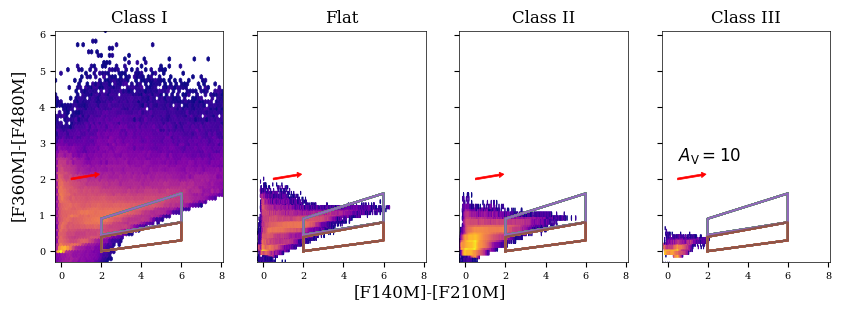

In [ ]:
import numpy as np
from astropy.table import Table
from astropy import constants,units as u
from sedfitter.sed import SEDCube
import matplotlib.pyplot as plt
from astroquery.svo_fps import SvoFps
from glob import glob
from tqdm.auto import tqdm
from dust_extinction.averages import CT06_MWLoc
from matplotlib.path import Path

def map_to_class(class_indices):
    return -1*(class_indices-3)

def extinct_colordiff(wav1,wav2,Av=10):
    return CT06_MWLoc()(wav1) * Av - CT06_MWLoc()(wav2) * Av

def energy_ok(g,ap_ind,pars):
    seds = SEDCube.read(f'{g}/flux.fits')
    dwav_over_wav = (seds.wav[:-1] - seds.wav[1:]) / ((seds.wav[1:] + seds.wav[:-1])/2)
    dwav_over_wav = dwav_over_wav.mean() # same value throughout b/c geomspaced
    dnu = (dwav_over_wav * seds.wav * constants.c / seds.wav**2).to(u.Hz)
    lum_integrals = (np.nansum(seds.val[:,ap_ind]*dnu, axis=-1) 
                     * 4*np.pi*(1*u.kpc)**2).to(u.L_sun).value
    ok = lum_integrals > 1e-4*pars['Model Luminosity']
    return ok

extinct = Table.read('FitzIndeb_3.1.txt',format='ascii')
'''
cam = 'NIRCam'
filters = SvoFps.get_filter_list(facility='JWST',instrument='NIRCam')
indices = [2,4,4,10]
x = -0.5; y = 2.5; offset = 1
xlim = np.array([-1.9,6.1]); ylim = np.array([-0.9,6.9]) #small apertures
nbins = [1300,300,300,300]
mincnts = [15,5,5,5]
#xlim = np.array([-2.9,9.1]); ylim = np.array([-1.9,9.9]) #big apertures
#nbins = [1000,150,150,350]
#mincnts = [15,5,5,5]
'''
filters = SvoFps.get_filter_list(facility='JWST')
filters.add_index('filterID')

polygons = {
    "".join(['JWST/NIRCam.F140M', 'JWST/NIRCam.F210M', 'JWST/NIRCam.F360M', 'JWST/NIRCam.F480M', ]):
    ([(2,0.45), (2,0.9), (6, 1.6), (6, 0.8)],
     [(2,0), (2,0.4 ), (6, 0.8), (6, 0.3)])
}

basepath = '/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/'

for filternames in (['JWST/NIRCam.F140M', 'JWST/NIRCam.F210M', 'JWST/NIRCam.F360M', 'JWST/NIRCam.F480M', ],
                    ['JWST/NIRCam.F277W', 'JWST/MIRI.F770W', 'JWST/NIRCam.F277W', 'JWST/MIRI.F1000W'],
                    ['JWST/NIRCam.F150W', 'JWST/MIRI.F770W', 'JWST/MIRI.F770W', 'JWST/MIRI.F1000W'],
                    ['JWST/NIRCam.F200W', 'JWST/NIRCam.F277W', 'JWST/NIRCam.F200W', 'JWST/MIRI.F770W'],):
    #indices = [0,2,2,10]
    #x = 1; y = 5; offset = 0.5
    #xlim = np.array([-0.3,10.1])
    #ylim = np.array([-0.3,7.1])
    #indices = [0,1,1,7]
    x = 0.5; y = 2; offset = 0.5
    xlim = np.array([-0.3,8.1]); ylim = np.array([-0.3,6.1]) #small apertures
    nbins = [1300,800,800,1000]
    mincnts = [15,5,5,5]
    #xlim = np.array([-3.1,11.1]); ylim = np.array([-3.1,9.1]) #big apertures
    #nbins = [1000,450,450,600]
    #mincnts = [15,3,3,3]
    #'''
    
    names = filters.loc[filternames]['filterID']
    insts = [n.split('/')[1].split('.')[1] for n in names]
    wavelengths = filters.loc[filternames]['WavelengthRef']
    
    zeropoints = filters.loc[filternames]['ZeroPoint']*1000
    colors = [(names[0],names[1]),(names[2],names[3])]
    combos = [(colors[0],colors[1])]
    exts = [extinct_colordiff(wavelengths.quantity[0],wavelengths.quantity[1]),
            extinct_colordiff(wavelengths.quantity[2],wavelengths.quantity[3])]
    
    all_gs = glob('../r+24_models-1.2.1/s*')
    ap_ind = 3
    
    #assign classes based on spectral index
    class_dict = {}
    classpoints = np.array([-1.6,-0.3,0.3,np.inf])
    for g in tqdm(all_gs):
        geo = g.split('/')[-1]
        indices = Table.read(f'../spectral_indices/{geo}.fits')
        obs_class = np.searchsorted(classpoints,indices['Spectral Index'][:,ap_ind],side='right')
        obs_class = map_to_class(np.array(obs_class))
        class_dict.update({g:obs_class})


    matched_indexes = {}

    fnstr = "".join(filternames)

    
    class_names = ['Class I','Flat','Class II','Class III']
    fig, ax = plt.subplots(1,len(class_names),figsize=(10,3),sharex=True,sharey=True)
    for i in tqdm(range(len(class_names))):
        c1 = []; c2 = []
        for g in (all_gs):
            matched_indexes[g] = []
            class_cut = class_dict[g] == i
            for ii, (color1,color2) in enumerate(combos):
                tbs = {cname:Table.read(f'{g}/convolved/{cname}.fits')
                       for cname in color1 + color2}
                keys1 = [col for col in color1]
                keys2 = [col for col in color2]
    
                colorp1 = -2.5*np.log10(tbs[keys1[0]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii]) + 2.5*np.log10(tbs[keys1[1]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii+1])
                colorp2 = -2.5*np.log10(tbs[keys2[0]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii+2]) + 2.5*np.log10(tbs[keys2[1]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii+3])
            
                c1.extend(colorp1); c2.extend(colorp2)
                
                if fnstr in polygons:
                    
                    for pg in polygons[fnstr]:
                        xx, yy = zip(*pg)
                        xx = xx + (xx[0],)
                        yy = yy + (yy[0],)
                        vertices = np.array(list(zip(xx, yy)))
                        ax[i].plot(xx, yy)
                    ptbl = Table.read(f'{basepath}/{g}/parameters.fits')

                    path = Path(vertices)
                    if len(colorp1) > 0:
                        incl = path.contains_points(list(zip(colorp1, colorp2)))
                    
                        matched_indexes[g].extend(ptbl['MODEL_NAME'][class_cut][incl])
                        #print(g, incl.sum())
    
        c1,c2 = np.array(c1),np.array(c2)
        toplot = np.logical_and(np.isfinite(c1),np.isfinite(c2))
        c1,c2 = c1[toplot],c2[toplot]
        ax[i].hexbin(c1,c2,gridsize=nbins[i],mincnt=mincnts[i],
                         bins='log',cmap='plasma')
        ax[i].set_title(class_names[i],fontsize='large')

    
    width = 0.05
    color = 'r'
    
    ax[0].set_xlim(xlim)
    ax[0].set_ylim(ylim)
    
    ax[0].arrow(x,y,*exts,width=width,color=color)
    ax[1].arrow(x,y,*exts,width=width,color=color)
    ax[2].arrow(x,y,*exts,width=width,color=color)
    ax[3].arrow(x,y,*exts,width=width,color=color)
    ax[3].text(x,y+offset,r'$A_{\rm V} = 10$',fontsize='large')
    
    fig.supxlabel(f'[{insts[0]}]-[{insts[1]}]',y=-0.02,fontsize='large')
    fig.supylabel(f'[{insts[2]}]-[{insts[3]}]',x=0.08,fontsize='large')
    
    name = "-".join([x.split(".")[-1] for x in filternames])
    
    #plt.savefig(f'/orange/adamginsburg/robitaille_models/modelgrids/ccds/hexbin_{name}_class_ccd.pdf',dpi=300,bbox_inches='tight')
    break

18
../r+24_models-1.2.1/s-ubhmi 4
../r+24_models-1.2.1/s-ubsmi 6
../r+24_models-1.2.1/sp--s-i 59
../r+24_models-1.2.1/s-u-hmi 0
../r+24_models-1.2.1/spubhmi 1
../r+24_models-1.2.1/s-p-hmi 0
../r+24_models-1.2.1/sp--h-i 23
../r+24_models-1.2.1/s-pbsmi 3
../r+24_models-1.2.1/s---s-i 0
../r+24_models-1.2.1/s-u-smi 0
../r+24_models-1.2.1/s-pbhmi 0
../r+24_models-1.2.1/spu-hmi 0
../r+24_models-1.2.1/sp--smi 0
../r+24_models-1.2.1/spu-smi 0
../r+24_models-1.2.1/spubsmi 0
../r+24_models-1.2.1/sp--hmi 0
../r+24_models-1.2.1/s---smi 0
../r+24_models-1.2.1/s-p-smi 0


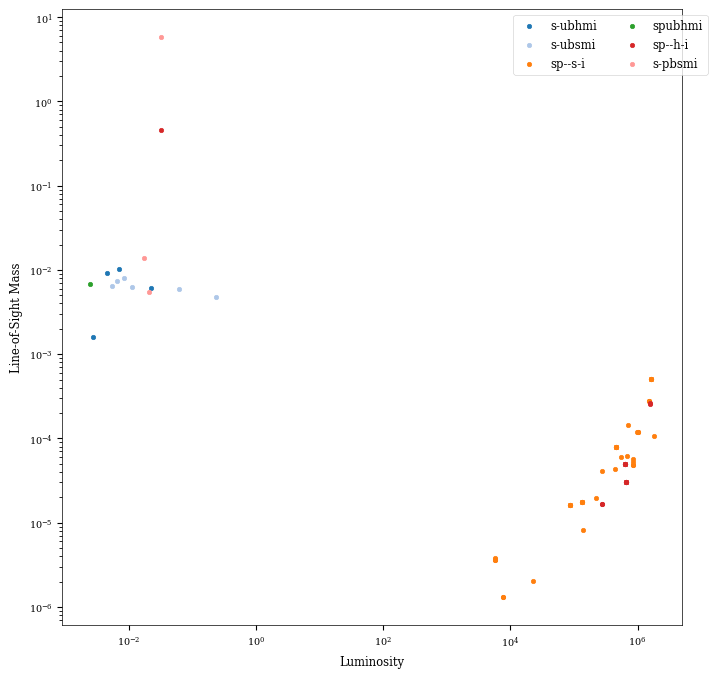

In [57]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
print(len(matched_indexes))
cmap = plt.get_cmap('tab20')

for ii, geo in enumerate(all_gs):
    print(geo, len(matched_indexes[geo]))
    ptbl = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/{geo.split("/")[-1]}/parameters.fits')
    ptbl.add_index('MODEL_NAME')
    ttt = ptbl.loc[matched_indexes[f'{geo}']]
    if len(ttt) == 0:
        continue
    try:
        ax.scatter(ttt['Source Luminosity'], ttt['Line-of-Sight Masses'][:, 3], color=cmap(ii / len(all_gs)), label=geo.split('/')[-1], s=10 )
    except Exception as e:
        print(f'{geo} has no matches')
        print(e)
ax.set_xlabel('Luminosity')
ax.set_ylabel('Line-of-Sight Mass')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize='small', ncol=2, bbox_to_anchor=(1.05, 1))

Text(0, 0.5, 'Flux (Jy)')

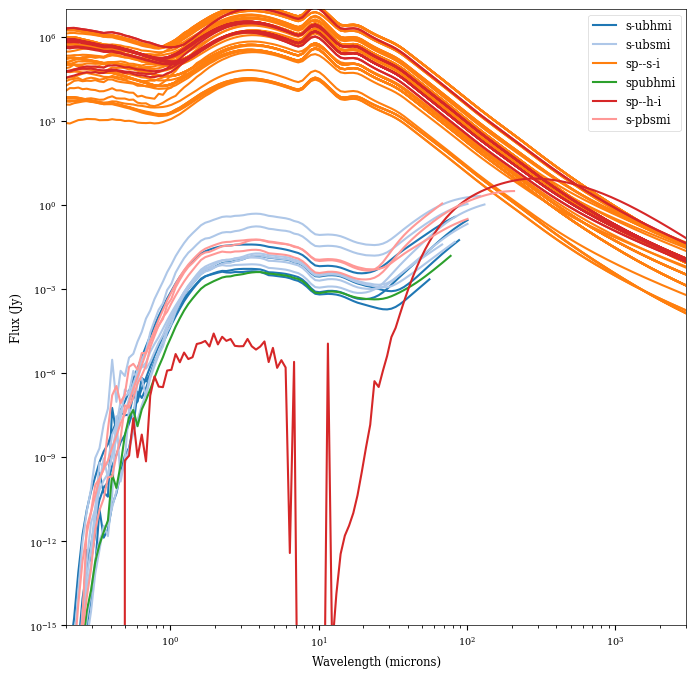

In [53]:
fit = plt.figure(figsize=(8,8))
ax = fit.add_subplot(111)
cmap = plt.get_cmap('tab20')

for ii, geo in enumerate(all_gs):
    seds = SEDCube.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/{geo.split("/")[-1]}/flux.fits')
    match = np.isin(seds.names, matched_indexes[geo])

    vals = seds.val[match, 3]   # shape: (n_match, n_wav)
    if vals.shape[0] == 0:
        continue

    for jj, val in enumerate(vals):
        if jj == 0:
            ax.plot(seds.wav, val, label=geo.split("/")[-1], color=cmap(ii / len(all_gs)))
        else:
            ax.plot(seds.wav, val, color=cmap(ii / len(all_gs)))

ax.loglog()
ax.set_xlim(0.2, 3000)
ax.set_ylim(1e-15,1e7)
ax.legend(fontsize='small')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Flux (Jy)')

In [ ]:
seds.wav

<Quantity [4.83863172e+03, 4.53135115e+03, 4.24358464e+03, 3.97409293e+03,
           3.72171547e+03, 3.48536542e+03, 3.26402494e+03, 3.05674083e+03,
           2.86262044e+03, 2.68082780e+03, 2.51058002e+03, 2.35114394e+03,
           2.20183296e+03, 2.06200407e+03, 1.93105511e+03, 1.80842215e+03,
           1.69357708e+03, 1.58602533e+03, 1.48530372e+03, 1.39097850e+03,
           1.30264347e+03, 1.21991822e+03, 1.14244649e+03, 1.06989465e+03,
           1.00195027e+03, 9.38320744e+02, 8.78732052e+02, 8.22927580e+02,
           7.70667009e+02, 7.21725280e+02, 6.75891629e+02, 6.32968675e+02,
           5.92771572e+02, 5.55127213e+02, 5.19873485e+02, 4.86858568e+02,
           4.55940286e+02, 4.26985491e+02, 3.99869489e+02, 3.74475507e+02,
           3.50694187e+02, 3.28423116e+02, 3.07566384e+02, 2.88034174e+02,
           2.69742369e+02, 2.52612198e+02, 2.36569890e+02, 2.21546359e+02,
           2.07476908e+02, 1.94300947e+02, 1.81961734e+02, 1.70406131e+02,
           1.59584375e+02

In [ ]:
wavelengths.quantity.to(u.um)

<Quantity [1.40532325, 2.09545131, 3.62417609, 4.81819459] um>

In [ ]:
exts

[1.1962701078630593, 0.11210227501965564]

In [ ]:
tbs['JWST/NIRCam.F140M']

MODEL_NAME,TOTAL_FLUX,TOTAL_FLUX_ERR
,mJy,mJy
bytes30,float64[20],float64[20]
012vyWLZ_01,0.0 .. 0.0,0.0 .. 0.0
01NLsAxo_01,0.0 .. 0.0,0.0 .. 0.0
01NcC57M_01,3.7164483046581154e-07 .. 9.509073606750462e-06,3.693534154081135e-07 .. 6.728320840920787e-06
0253kK1Q_01,1046.665283203125 .. 2234.980224609375,14.0448579788208 .. 18.811790466308594
02jjDmgA_01,1.314065933227539 .. 1.3312915563583374,0.01871761865913868 .. 0.018718475475907326
02wfju3U_01,0.0 .. 0.0,0.0 .. 0.0
03Izsw7d_01,0.0 .. 2029.47412109375,0.0 .. 222.7660369873047
03W416Iy_01,45.04400634765625 .. 57.20798110961914,0.39571070671081543 .. 0.5190118551254272
